In [1]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

from modelbase.ode import Model, Simulator
from modelbase.ode import ratelaws as rl

Could not find cannot import name 'dopri5' from 'assimulo.lib' (C:\Users\Tanvir Hassan\anaconda3\envs\mibinet\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (C:\Users\Tanvir Hassan\anaconda3\envs\mibinet\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (C:\Users\Tanvir Hassan\anaconda3\envs\mibinet\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


In [2]:
# Create a Model object
m = Model()

In [3]:
# Define model parameters
parameters = {
    'Kl' : 200,  # Michaelis constant for light (μmol photons m⁻² s⁻¹)
    'Kc' : 300, # Michaelis constant for CO2 (ppm)
    'k' : 0.8,  # Conversion factor from photosynthesis rate to sucrose production rate
    'P_max':0.13,  # Maximal net rate of photosynthesis (μmol O2 s⁻¹ mg chl a⁻¹)
    'L0' : 1000,  # Intensity of incident light (μmol photons m⁻² s⁻¹)
    'S_f': 1.0, # Illuminated surface area of the reactor (m²)
    'V' : 0.01,  # Reactor's liquid volume (L)
    'epsilon' : 0.000001, # Extinction Coefficient
    'mu_max' : .05,  # Maximum specific growth rate (1/s)
    'K_s' : 0.1, # Half-saturation constant for growth (μmol sucrose/L)
    'm' : 0.02,  # Mortality rate (1/s)
    'Cr' : 500,  # Fixed CO2 concentration (ppm)
    'Kp' : 0.1,  # Half-saturation constant for public metabolizer growth (μmol glucose/L)
    'KD' : 0.2, # Half-saturation constant for cheater metabolizer growth (μmol glucose/L)
    'eP' : 0.001 ,  # Conversion rate of sucrose to glucose by public metabolizers (1/s)
    'cost': 0.00005  # Cost of producing public enzymes (1/s)
}



In [4]:
# Add parameters to the model
m.add_parameters(parameters)

In [5]:
# Add compounds to the model
m.add_compounds(['C','P','D','G'])

In [6]:
def base_rate(L0, Kl ,Cr, Kc, P_max):
    return  P_max * L0 / (Kl+L0) * Cr / (Kl + Cr) 
# Add reactions to the model
m.add_algebraic_module_from_args(
    module_name='base_rate',
    function= base_rate,
    derived_compounds=["base_rate"],
    args=["L0", "Kl" ,"Cr", "Kc", "P_max"]
)

In [7]:
def photosynthesis_rate ( k ,base_rate, C):
    return  k * base_rate * C


# Add reactions to the model
m.add_algebraic_module_from_args(
    module_name='photosynthesis_rate',
    function= photosynthesis_rate,
    derived_compounds=["photosynthesis_rate"],
    args=["k" ,"base_rate", "C"]
)

In [135]:
def S_t (L0 , S_f, V, epsilon, C):
    return  L0  * (S_f/V) * epsilon * C


# Add reactions to the model
m.add_algebraic_module_from_args(
    module_name='S_t',
    function= S_t,
    derived_compounds=["S_t"],
    args=["L0" , "S_f", "V", "epsilon", "C"]
)

In [136]:
# "L0" , "S_f", "V", "epsilon", "C"
m.parameters["epsilon"]

1e-06

In [137]:
def S_h(photosynthesis_rate, S_t):
    return photosynthesis_rate - S_t

m.add_algebraic_module_from_args(
    module_name = "S_h",
    function = S_h,
    derived_compounds = ["S_h"],
    args = ["photosynthesis_rate", "S_t"]
)

In [138]:
def μ_c(mu_max,K_s,S_t):
    return  mu_max* S_t/(K_s+S_t)

# Add reactions to the model
m.add_algebraic_module_from_args(
    module_name='μ_c',
    function= μ_c,
    derived_compounds=['μ_c'],
    args=["mu_max", "K_s", "S_t"]
)

In [139]:
m.compounds

['C', 'P', 'D', 'G']

In [140]:
def Cyano(C, μ_c, m):
    return  μ_c  * C - m * C


# Add reactions to the model
m.add_reaction_from_args(
    rate_name='Cyano',
    function= Cyano,
    stoichiometry={'C':1},
    args=["C", "μ_c", "m"],
    reversible=False
)

In [141]:
def μ_p(mu_max,Kp,G):
    return  mu_max* G/(Kp+G)

# Add reactions to the model
m.add_algebraic_module_from_args(
    module_name='μ_p',
    function= μ_p,
    derived_compounds=['μ_p'],
    args=["mu_max", "Kp", "G"]
)

In [142]:
def Public(P, μ_p, m,cost):
    return  μ_p  * P - m * P - cost* P


# Add reactions to the model
m.add_reaction_from_args(
    rate_name='Public',
    function= Public,
    stoichiometry={'P':1},
    args=["P", "μ_p", "m","cost"],
    reversible=False
)

In [143]:
def μ_D(mu_max,KD,G):
    return  mu_max * G/(KD+G)

# Add reactions to the model
m.add_algebraic_module_from_args(
    module_name='μ_D',
    function= μ_D,
    derived_compounds=['μ_D'],
    args=["mu_max", "KD", "G"]
)

In [144]:
def cheater(D,μ_D,m):
    return  μ_D  * D - m * D 


# Add reactions to the model
m.add_reaction_from_args(
    rate_name='cheater',
    function= cheater,
    stoichiometry={'D':1},
    args=["D", "μ_D", "m"],
    reversible=False
)

In [145]:
def G ( eP, S_h, P):
    return  eP * S_h* P 


# Add reactions to the model
m.add_reaction_from_args(
    rate_name='G',
    function= G,
    stoichiometry={'G':1},
    args=[ "eP", "S_h", "P"],
    reversible=False
)

In [146]:
m.get_stoichiometric_df()

,Cyano,G,Public,cheater
C,1.0,0.0,0.0,0.0
D,0.0,0.0,0.0,1.0
G,0.0,1.0,0.0,0.0
P,0.0,0.0,1.0,0.0


In [147]:
y0 = {'C':1000, 'P':10, 'D':10,'G':10 }

In [ ]:
s.plot_selection("G")
plt.xlabel('Time (hour)')
plt.ylabel('Glucose')

In [ ]:
s.get_full_results_df()

In [ ]:
m.get_stoichiometric_df()

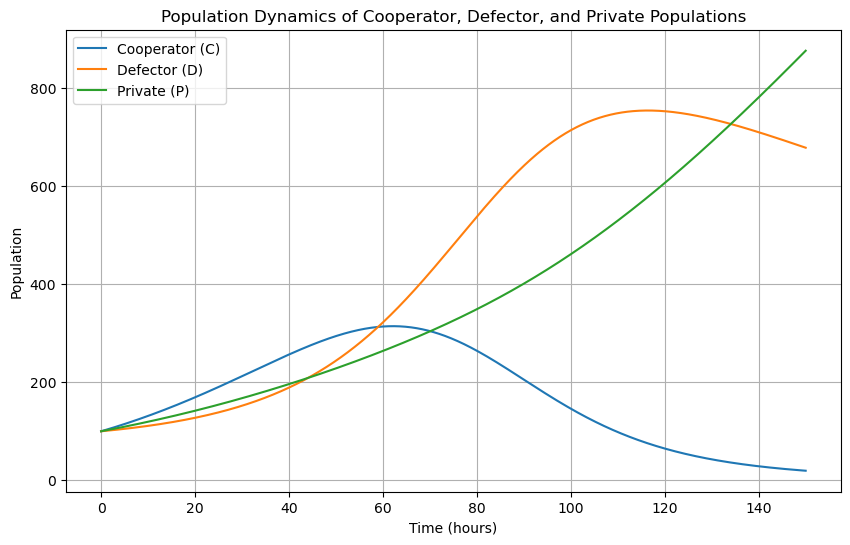

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from modelbase.ode import Model, Simulator

# Create a Model object
m = Model()

# Define model parameters
parameters = {
    'beta': 0.00001,       # competition parameter between public and private
    'gamma': 0.00001,      # cost for private population
    'alpha': 0.0001,       # benefit from cooperator to defector
    'mu': 0.04,            # growth rate of cooperator
    'eta': 0.02,           # growth rate of private population
    'nu': 0.00001,         # transportation cost of defector
}

# Add parameters to the model
m.add_parameters(parameters)

# Add compounds to the model
m.add_compounds(['C', 'D', 'P'])

# Define the growth rate for cooperator (C)
def cooperator_growth(mu, C, alpha, D, beta, P):
    return mu * C - alpha * C * D - beta * C * P - beta * C * C

m.add_reaction_from_args(
    rate_name='cooperator_growth',
    function=cooperator_growth,
    stoichiometry={'C': 1},
    args=['mu', 'C', 'alpha', 'D', 'beta', 'P'],
    reversible=False
)

# Define the growth rate for defector (D)
def defector_growth(alpha, C, D, nu):
    return alpha * C * D - nu * D * D

m.add_reaction_from_args(
    rate_name='defector_growth',
    function=defector_growth,
    stoichiometry={'D': 1},
    args=['alpha', 'C', 'D', 'nu'],
    reversible=False
)

# Define the growth rate for private (P)
def private_growth(eta, P, beta, C, gamma):
    return eta * P - beta * C * P - gamma * P * P

m.add_reaction_from_args(
    rate_name='private_growth',
    function=private_growth,
    stoichiometry={'P': 1},
    args=['eta', 'P', 'beta', 'C', 'gamma'],
    reversible=False
)

# Initial conditions
y0 = {'C': 100.0, 'D': 100.0, 'P': 100.0}

# Create a Simulator object
s = Simulator(m)

# Initialize the simulator with initial conditions
s.initialise(y0)

# Simulate over a time span of 150 hours with 1000 steps
s.simulate(150, steps=1000)

# Extract the population data from the simulator
time = s.get_time()
C = s.get_variable('C')
D = s.get_variable('D')
P = s.get_variable('P')

# Plot the dynamics of each population
plt.figure(figsize=(10, 6))
plt.plot(time, C, label='Cooperator (C)')
plt.plot(time, D, label='Defector (D)')
plt.plot(time, P, label='Private (P)')
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.title('Population Dynamics of Cooperator, Defector, and Private Populations')
plt.show()
